# EEG-Based Classification of Major Depressive Disorder (MDD)

This notebook builds a patient-level EEG classification pipeline for distinguishing MDD from healthy controls using the nm000114 dataset. The workflow covers data ingestion, metadata construction, channel standardization, feature extraction, baseline model comparison, condition-speficic analysis, and simple augmentation experiments.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from pathlib import Path 

from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix, 
    ConfusionMatrixDisplay
)
from sklearn.base import clone

## 2. Project paths

In [2]:
def find_project_root():
    p = Path.cwd()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    raise FileNotFoundError("Project root (with .git) not found")

PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "nm000114"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed_features"
RESULTS_DIR = PROJECT_ROOT / "results"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DATA_DIR:", RAW_DATA_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

PROJECT_ROOT: d:\eeg-mdd-classification
RAW_DATA_DIR: d:\eeg-mdd-classification\data\raw\nm000114
PROCESSED_DIR: d:\eeg-mdd-classification\data\processed_features
RESULTS_DIR: d:\eeg-mdd-classification\results


## 3. Build the metadata table

In [3]:
def get_eeg_file(subject_id: str, condition: str):
    """ Get the path to the EEG file for a given subject and condition.
    """
    return RAW_DATA_DIR / subject_id / "eeg" / f"{subject_id}_task-{condition}_eeg.edf"

def infer_label_from_subject(subject_id: str) -> int:
    """
    Infer the label (0 for healthy control, 1 for MDD) from the subject ID.
    """
    subject_upper = subject_id.upper()
    if "HS" in subject_upper:
        return 0
    elif "MDD" in subject_upper:
        return 1 
    else: 
        raise ValueError(f"Could not infer label from subject ID: {subject_id}")
    
def parse_condition_from_filename(filepath: Path) -> str:
    """
    Parse the condition (eyesClosed, eyesOpen, P300) from the filename.
    """
    name = filepath.name 
    if "task-eyesClosed" in name:
        return "eyesClosed"
    elif "task-eyesOpen" in name:
        return "eyesOpen"
    elif "task-P300" in name:
        return "P300"
    else:
        raise ValueError(f"Could not parse condition from filename: {name}")
        
edf_files =sorted(RAW_DATA_DIR.glob("sub*/eeg/*.edf"))
        
rows = []
for filepath in edf_files:
    subject_id = filepath.parts[-3] 
    rows.append({
        "patient_id": subject_id,
        "recording_id": filepath.stem,
        "label": infer_label_from_subject(subject_id),
        "condition": parse_condition_from_filename(filepath),
        "filepath": str(filepath),
    })


# Create a DataFrame from the metadata
metadata_df = pd.DataFrame(rows)
metadata_df.head()        

,patient_id,recording_id,label,condition,filepath
0,sub-HS1,sub-HS1_task-eyesClosed_eeg,0,eyesClosed,d:\eeg-mdd-classification\data\raw\nm000114\su...
1,sub-HS1,sub-HS1_task-eyesOpen_eeg,0,eyesOpen,d:\eeg-mdd-classification\data\raw\nm000114\su...
2,sub-HS1,sub-HS1_task-P300_eeg,0,P300,d:\eeg-mdd-classification\data\raw\nm000114\su...
3,sub-HS10,sub-HS10_task-eyesClosed_eeg,0,eyesClosed,d:\eeg-mdd-classification\data\raw\nm000114\su...
4,sub-HS10,sub-HS10_task-eyesOpen_eeg,0,eyesOpen,d:\eeg-mdd-classification\data\raw\nm000114\su...


## 4. Exploratory data summary

In [4]:
print("Shape:", metadata_df.shape)
print("\nUnique patients:", metadata_df["patient_id"].nunique())
print("\nClass counts:")
print(metadata_df["label"].value_counts())
print("\nCondition counts:")
print(metadata_df["condition"].value_counts())
print("\nRecordings per patient:")
print(metadata_df.groupby("patient_id").size().value_counts())

metadata_path = PROCESSED_DIR / "metadata.csv"
metadata_df.to_csv(metadata_path, index=False)
print("\nMetadata saved to:", metadata_path)

Shape: (181, 5)

Unique patients: 64

Class counts:
label
1    95
0    86
Name: count, dtype: int64

Condition counts:
condition
eyesOpen      62
P300          61
eyesClosed    58
Name: count, dtype: int64

Recordings per patient:
3    52
2    10
4     1
1     1
Name: count, dtype: int64

Metadata saved to: d:\eeg-mdd-classification\data\processed_features\metadata.csv


## 5. Standardize channels

A subset of files contains two auxiliary channels (EEG 23A-23R, EEG 24A-24R) that are not present in all recordings. To ensure a consistent feature length, analysis is restricted to the 20 EEG channels shared across all files. 

In [5]:
COMMON_CHANNELS = [
'EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE',
 'EEG F7-LE', 'EEG T3-LE', 'EEG T5-LE', 'EEG Fz-LE', 'EEG Fp2-LE', 
 'EEG F4-LE', 'EEG C4-LE', 'EEG P4-LE', 'EEG O2-LE', 'EEG F8-LE', 
 'EEG T4-LE', 'EEG T6-LE', 'EEG Cz-LE', 'EEG Pz-LE', 'EEG A2-A1'
]

print("Number of common channels:", len(COMMON_CHANNELS))


Number of common channels: 20


## 6. Extract relative band-power features

In [6]:
def extract_band_power(raw, COMMON_CHANNELS) -> np.ndarray:
    """
    Extract relative band-power features for each EEG channel in the raw MNE object.
    Returns a feature vector.
    """

    data_raw = raw.copy()
    data_raw.pick(COMMON_CHANNELS)
    
    # get data 
    data = data_raw.get_data()      # shape: (n_channels, n_time points)
    sfreq = data_raw.info['sfreq']  # sampling frequency (e.g. 256 Hz)

    # Define frequency bands 
    bands = {
        "delta": (1, 4),     # deep sleep
        "theta": (4, 8),     # drowsiness
        "alpha": (8, 13),    # relaxed 
        "beta":  (13, 30)    # active thinking 
    }

    all_features = []

    # Loop through each channel (ch) and convert signal to frequency domain using Welch's method to estimate power spectral density (psd)
    for ch in data:        
        psd, freqs = mne.time_frequency.psd_array_welch(
            ch,
            sfreq=sfreq,
            fmin=1,
            fmax=30,
            verbose=False
        )

        total_power = psd.sum()
        
        band_features = [
            (
                psd[(freqs >= fmin) & (freqs <= fmax)].mean()
            / total_power                                      # normalize by total power to get relative power in each band
            if total_power > 0 else 0                          # handle case where total power is zero to avoid division by zero
            )                           
            for (fmin, fmax) in bands.values()
            ]
    
        all_features.append(band_features)

    return np.nan_to_num(np.array(all_features).flatten())



## 7. Build the feature matrix 

In [7]:
# Build feature matrix 

records = [
    (
        extract_band_power(
            mne.io.read_raw_edf(row["filepath"], preload=True, verbose=False),
            COMMON_CHANNELS
        ),
        row["label"],
        row["patient_id"]
    )
    for _, row in metadata_df.iterrows()
]

X = np.vstack([r[0] for r in records])
y = np.array([r[1] for r in records])
groups = np.array([r[2] for r in records])

print("X.shape:", X.shape)
print("y.shape:", y.shape)
print("Groups shape:", groups.shape)


X.shape: (181, 80)
y.shape: (181,)
Groups shape: (181,)


## 8. Define patient-level cross-validation and baseline models

In [ ]:
gfk = GroupKFold(n_splits=5)

gfk = GroupKFold(n_splits=5)

pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, random_state=42))
])

pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf",probability=True, random_state=42))
])

## 9. Compare Logistic Regression and SVM

In [9]:
results_lr = cross_validate(
    pipeline_lr, 
    X, 
    y,
    cv=gfk.split(X, y, groups=groups),
    scoring=["accuracy", "f1", "roc_auc"]
)

results_svm = cross_validate(
    pipeline_svm,
    X,
    y,
    cv=gfk.split(X, y, groups=groups),
    scoring=["accuracy", "f1", "roc_auc"]
)

comparison_df = pd.DataFrame({
    "Model": ["LogisticRegression", "SVM"],
    "Accuracy": [results_lr["test_accuracy"].mean(), results_svm["test_accuracy"].mean()],
    "F1 Score": [results_lr["test_f1"].mean(), results_svm["test_f1"].mean()],
    "ROC-AUC": [results_lr["test_roc_auc"].mean(), results_svm["test_roc_auc"].mean()]
})

comparison_df

,Model,Accuracy,F1 Score,ROC-AUC
0,LogisticRegression,0.762668,0.771849,0.839708
1,SVM,0.790163,0.812312,0.867992


### Interpretation:

The SVM model outperforms the Logistic Regression across all metrics, suggesting that the relationship between EEG band-power features and class labels is not strictly linear. The improvement in ROC-AUC indicates better overall class separability, while the higher F1 score reflects improved balance between precision and recall. 

## 10. Verify no patient-level leakage and inspect the best baseline confusion matrix

In [10]:
for fold, (train_idx, test_idx) in enumerate(gfk.split(X, y, groups), start=1):
    train_groups = set(groups[train_idx])
    test_groups = set(groups[test_idx])
    overlap = train_groups.intersection(test_groups)

    assert len(overlap) == 0, f"Data leakage detected in fold {fold}! Overlapping groups: {overlap}"
print("No data leakage detected across folds!")

No data leakage detected across folds!


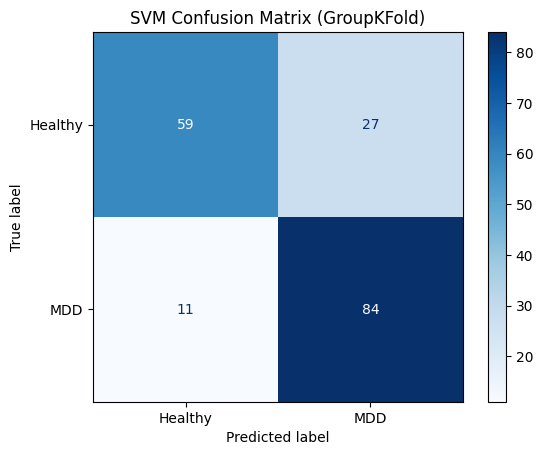

In [11]:
# confusion matrix 
y_pred_svm = cross_val_predict(
    pipeline_svm, 
    X,
    y,
    cv=gfk.split(X, y, groups)
)

cm_svm = confusion_matrix(y, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Healthy", "MDD"])
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.title("SVM Confusion Matrix (GroupKFold)")
plt.show()

### Confusion matrix interpretation

- MDD recall = 84 / (84+11) ~ 0.88
- Healthy recall = 59 / (59+27) ~ 0.69

The SVM model performs better at identifying MDD subjects than healthy controls, achieving high sensitivity for MDD (~88%) but lower specificity for healthy subjects(~69%). This indicates a bias toward predicting the positive MDD class, which may be beneficial in a clinical screening context but could lead to increased false positives.  

## 11. Compare EEG conditions using the best classical model (SVM)


In [12]:

def run_condition_model(condition_name, metadata_df, X, y, groups, model):
    """ Run the model separately for a specific condition (e.g. eyesClosed, eyesOpen, P300) to see if performance differs by condition.
    """
    mask = metadata_df["condition"] == condition_name

    X_cond = X[mask]
    y_cond = y[mask]
    groups_cond = groups[mask]

    results = cross_validate(
        model,
        X_cond,
        y_cond, 
        cv=GroupKFold(n_splits=5).split(X_cond, y_cond, groups_cond),
        scoring=["accuracy", "f1", "roc_auc"]
    )

    return {
        "Condition": condition_name,
        "Accuracy": results["test_accuracy"].mean(),
        "F1": results["test_f1"].mean(),
        "Roc-Auc": results["test_roc_auc"].mean()
    }

condition_results = pd.DataFrame([
    run_condition_model("eyesClosed", metadata_df, X, y, groups, pipeline_svm),
    run_condition_model("eyesOpen", metadata_df, X, y, groups, pipeline_svm),
    run_condition_model("P300", metadata_df, X, y, groups, pipeline_svm)
])

condition_results


,Condition,Accuracy,F1,Roc-Auc
0,eyesClosed,0.830303,0.829004,0.896667
1,eyesOpen,0.678205,0.707179,0.851508
2,P300,0.802564,0.837857,0.847460


### Interpretation of condition performance

Classification performance varies across the conditions 70% - 83% accuracy. The EyesClosed condition achieves the highest accuracy and ROC-AUC, suggesting that resting-state EEG provides the most dicriminative signal for MDD classification. In constrast, eyesOpen performs worse, most likely due to increased variability or noise. P300 achieves the highest F1 score, indicating a strong balance between precision and recall in task-based EEG.

## 12. Augmentation helpers

The augmentation experiments are applied only within training folds to avoid leakage into the held-out patients. 

In [ ]:
def augment_gaussian_noise(X, noise_std=0.01, random_state=42):
    """
    Add Gaussian noise to the feature matrix X.
    """
    rng = np.random.default_rng(random_state)
    noise = rng.normal(loc=0, scale=noise_std, size=X.shape)
    return X + noise

def augment_amplitude_scaling(X, scale_low=0.9, scale_high=1.1, random_state=42):
    """
    Randomly scale the amplitude of the features in X.
    """
    rng = np.random.default_rng(random_state)
    scales = rng.uniform(low=scale_low, high=scale_high, size=(X.shape[0], 1))
    return X * scales

## 13. Evaluate augmentation within patient-level GroupKFold

In [ ]:
def evaluate_with_augmentation(X, y, groups, model, augmenter=None, augmenter_kwargs=None):
    """ 
    Evaluate a model using GroupKFold cross-validation with optional data augmentation applied to the training folds.
    Args:        
        X: Feature matrix
        y: Target labels
        groups: Group labels for cross-validation
        model: The model to evaluate
        augmenter: The data augmentation function
        augmenter_kwargs: Keyword arguments for the augmenter   
    Returns: A dictionary containing the mean scores and scores by fold    
    """
    if augmenter_kwargs is None:
        augmenter_kwargs = {}

    cv = GroupKFold(n_splits=5)

    acc_scores = []
    f1_scores = []
    roc_auc_scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        if augmenter is not None:
            X_train_aug = augmenter(X_train, **augmenter_kwargs)
            y_train_aug = y_train.copy()

            X_train_final = np.vstack([X_train, X_train_aug])
            y_train_final = np.concatenate([y_train, y_train_aug])
        else:
            X_train_final = X_train
            y_train_final = y_train

        model_fold = clone(model)
        model_fold.fit(X_train_final, y_train_final)

        y_pred = model_fold.predict(X_test)
        y_prob = model_fold.predict_proba(X_test)[:, 1]

        acc_scores.append(accuracy_score(y_test, y_pred))
        f1_scores.append(f1_score(y_test, y_pred))
        roc_auc_scores.append(roc_auc_score(y_test, y_prob))

    return {
    "accuracy": np.mean(acc_scores),
    "f1": np.mean(f1_scores),
    "roc_auc": np.mean(roc_auc_scores),
    "acc_by_fold": acc_scores,
    "f1_by_fold": f1_scores, 
    "roc_auc_by_fold": roc_auc_scores,
    }


        

In [ ]:
def run_augmentation_experiment_for_condition(
        condition_name,
        metadata_df,
        X,
        y,
        groups,
        model,
        noise_std=0.01,
        scale_low=0.9,
        scale_high=1.1,
        random_state=42,
):
    """
    Run the augmentation experiment for a specific condition.
    """
    mask = metadata_df["condition"] == condition_name

    X_cond = X[mask]
    y_cond = y[mask]
    groups_cond = groups[mask]

    baseline_results = evaluate_with_augmentation(
        X_cond, 
        y_cond, 
        groups_cond, 
        model, 
        augmenter=None)

    gaussian_results = gaussian_results = evaluate_with_augmentation(
        X_cond,
        y_cond,
        groups_cond, 
        model,
        augmenter=augment_gaussian_noise,
        augmenter_kwargs={"noise_std": noise_std, "random_state": random_state},
    )

    scaling_results = evaluate_with_augmentation(
        X_cond,
        y_cond, 
        groups_cond, 
        model,
        augmenter=augment_amplitude_scaling,
        augmenter_kwargs={"scale_low": scale_low, "scale_high": scale_high, "random_state": random_state},
    )

    return pd.DataFrame([
        {
            "Condition": condition_name,
            "Augmentation": "None (Baseline)",
            "Accuracy": baseline_results["accuracy"],
            "F1 Score": baseline_results["f1"],
            "ROC-AUC": baseline_results["roc_auc"],
        },
        {
            "Condition": condition_name,
            "Augmentation": "Gaussian Noise",
            "Accuracy": gaussian_results["accuracy"],
            "F1 Score": gaussian_results["f1"],
            "ROC-AUC": gaussian_results["roc_auc"],
        },
        {
            "Condition": condition_name,
            "Augmentation": "Amplitude Scaling",
            "Accuracy": scaling_results["accuracy"],
            "F1 Score": scaling_results["f1"],
            "ROC-AUC": scaling_results["roc_auc"],
        }
    ])


## 14. Compare augmentation across P300 and eyesClosed

In [ ]:
p300_aug_results = run_augmentation_experiment_for_condition(
    "P300",
    metadata_df,
    X,
    y,
    groups,
    pipeline_svm
)

eyes_closed_aug_results = run_augmentation_experiment_for_condition(
    "eyesClosed",
    metadata_df,
    X,
    y,
    groups,
    pipeline_svm,
)

combined_aug_results = pd.concat(
    [p300_aug_results, eyes_closed_aug_results],
    ignore_index=True,
)

combined_aug_results

,Condition,Augmentation,Accuracy,F1 Score,ROC-AUC
0,P300,None (Baseline),0.802564,0.837857,0.847460
1,P300,Gaussian Noise,0.802564,0.837857,0.831587
2,P300,Amplitude Scaling,0.785897,0.826190,0.864127
3,eyesClosed,None (Baseline),0.830303,0.829004,0.896667
4,eyesClosed,Gaussian Noise,0.830303,0.829004,0.890000
5,eyesClosed,Amplitude Scaling,0.863636,0.863403,0.896667


### Interpretation:

The effectiveness of augmentation depends strongly on the EEG condition. For P300 data, neither Gaussian noise or amplitude scaling improved classification performance, suggesting that task-based signals may already capture sufficient discriminative structure. In constrast, amplitude scaling improved performance in the eyesClosed condition, indicating that simple transformations can enhance variability in resting-state EEG and improve generalization.  


## 15. Visualize augmentation results

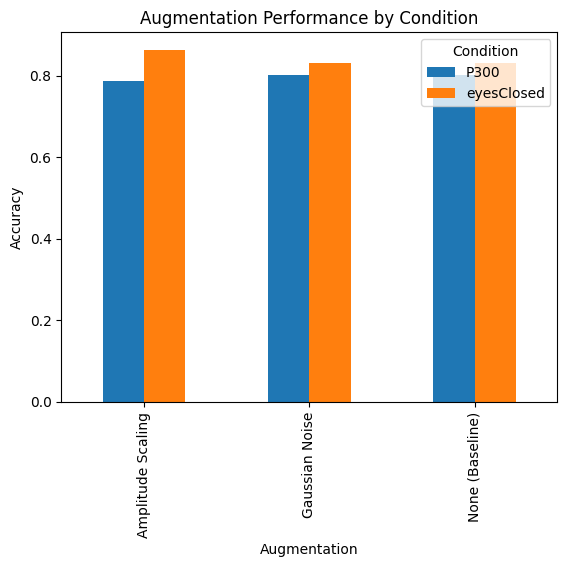

In [ ]:
combined_aug_results.pivot(
    index="Augmentation",
    columns="Condition",
    values="Accuracy",
).plot(kind="bar")

plt.ylabel("Accuracy")
plt.title("Augmentation Performance by Condition")
plt.show()

## 16. Summary 

At this stage, the notebook provides:

    - a reproducible metadata and feature-extraction pipeline,
    - patient-level evaluation with GroupKFold
    - baseline comparison between Logistic Regression and SVM,
    - condition-specific modeling across eyesClosed, eyesOpen, and P300,
    - and simple augmentation experiments on the strongest conditions. 

This provides the control/baseline framework for comparing more advanced generative augmentation methods such as VAE and GAN. 